In [28]:
!pip install scanpy anndata seaborn matplotlib pandas numpy scikit-learn

In [29]:
import scanpy as sc

# This automatically downloads the 3k PBMC dataset from an active mirror and saves it locally
adata = sc.datasets.pbmc3k()

# Quick view of target single-cell object matrix
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


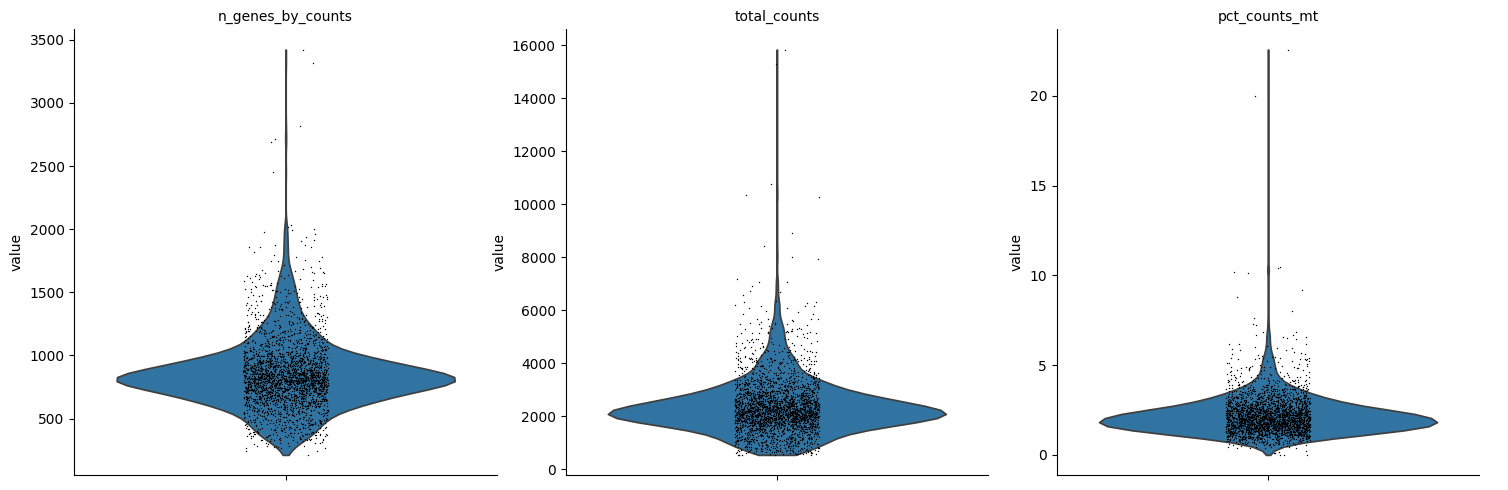

In [30]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts",
     "total_counts",
     "pct_counts_mt"],
    multi_panel=True
)

adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

In [31]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/tmp/ipykernel_3606/3052528762.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


In [32]:
adata.raw = adata.copy()

In [33]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000
)

adata = adata[:, adata.var.highly_variable]

In [34]:
sc.pp.scale(adata, max_value=10)

/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [35]:
import os

os.makedirs(
    "figures",
    exist_ok=True
)

os.makedirs(
    "results",
    exist_ok=True
)

/tmp/ipykernel_3606/3584585908.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(


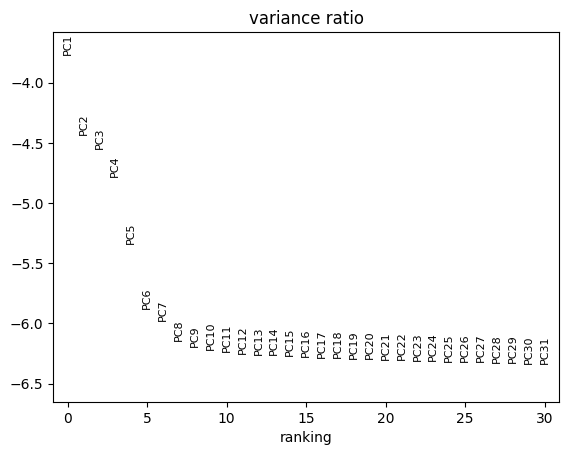

In [36]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(
    adata,
    log=True,
    save="_variance.png"
)

In [37]:
!pip install leidenalg
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, flavor='igraph')

/tmp/ipykernel_3606/1811777130.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


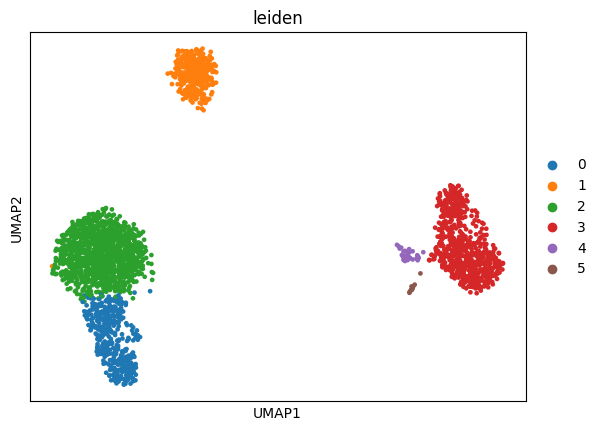

In [38]:
sc.pl.umap(
    adata,
    color=["leiden"],
    save="_clusters.png"
)

/tmp/ipykernel_3606/2523410014.py:15: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


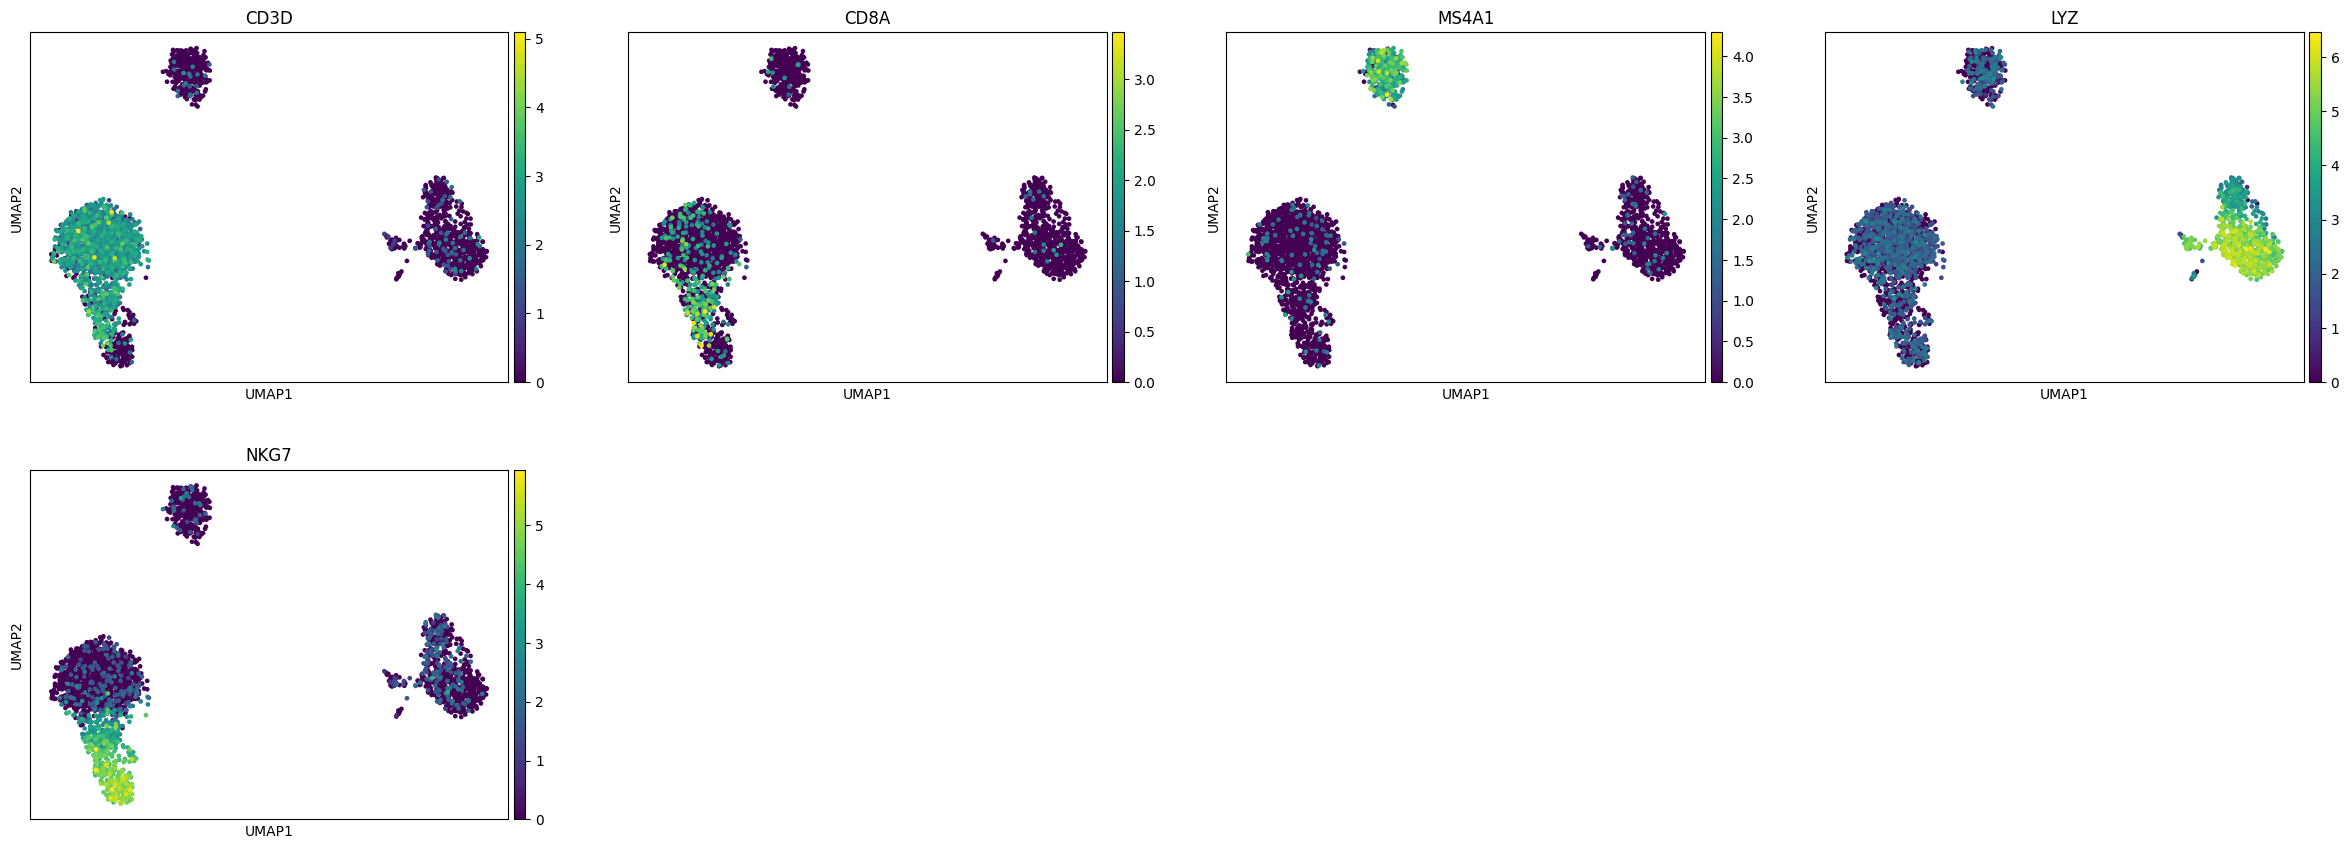

In [39]:
marker_genes = [
    "CD3D",
    "CD8A",
    "MS4A1",
    "LYZ",
    "NKG7"
]

present_marker_genes = [
    gene
    for gene in marker_genes
    if gene in adata.raw.var_names
]

sc.pl.umap(
    adata,
    color=present_marker_genes,
    use_raw=True,
    save="_markers.png"
)

In [40]:
celltype_map = {
    "0": "T Cells",
    "1": "NK Cells",
    "2": "B Cells",
    "3": "Monocytes"
}

adata.obs["cell_type"] = (
    adata.obs["leiden"]
    .map(celltype_map)
)

/tmp/ipykernel_3606/3496294339.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


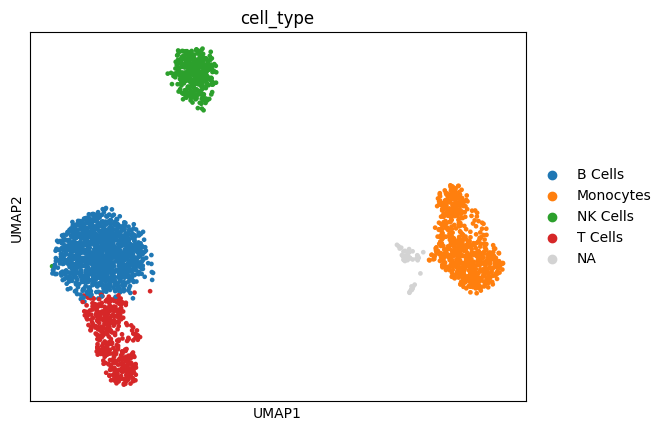

In [41]:
sc.pl.umap(
    adata,
    color="cell_type",
    save="_celltypes.png"
)

In [42]:
sc.tl.rank_genes_groups(
    adata,
    "leiden",
    method="wilcoxon"
)

/tmp/ipykernel_3606/1458068680.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_genes_groups(


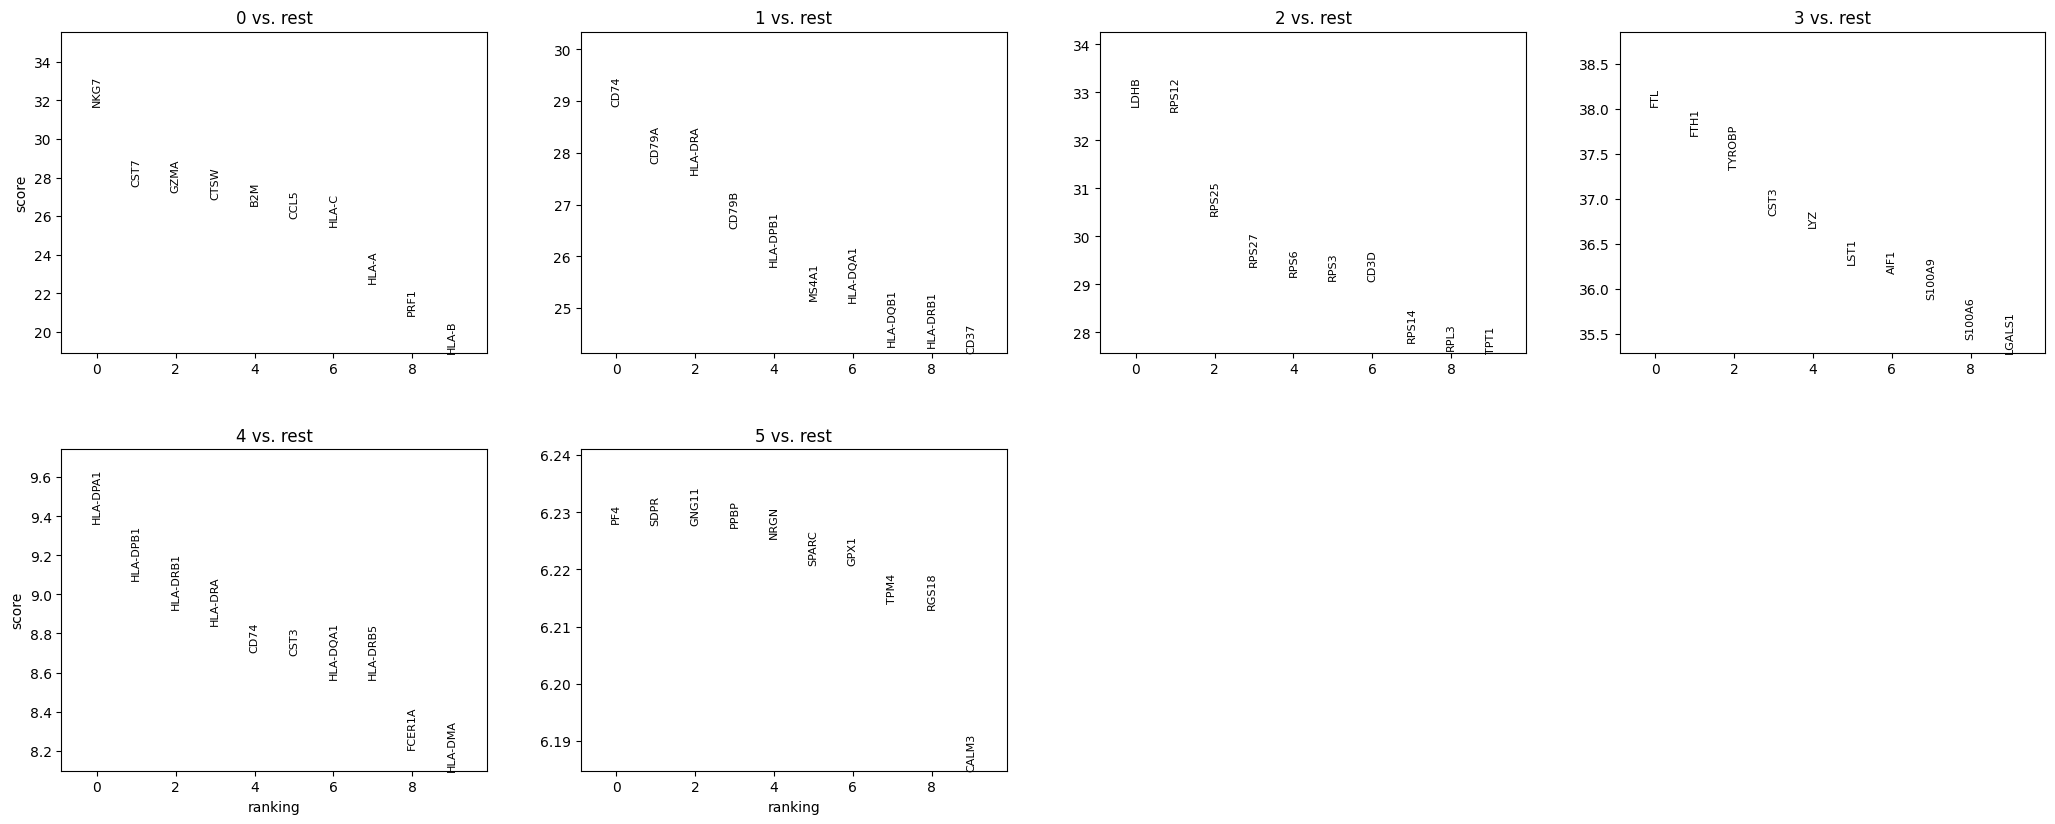

In [43]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False,
    save="_top_markers.png"
)

/tmp/ipykernel_3606/4052946688.py:6: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_genes_groups_heatmap(


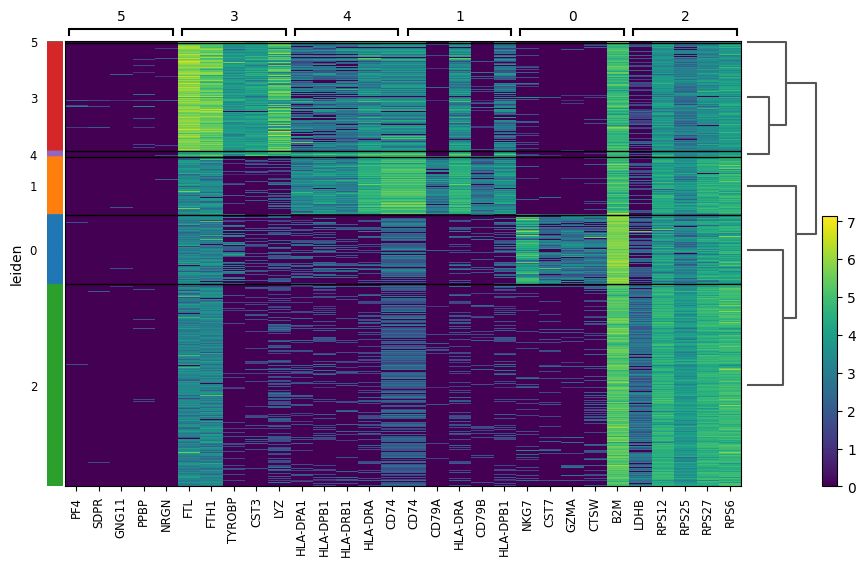

In [44]:
sc.tl.dendrogram(
    adata,
    groupby="leiden"
)

sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=5,
    groupby="leiden",
    show_gene_labels=True,
    save="_heatmap.png"
)

In [45]:
adata.write("pbmc_scRNA_processed.h5ad")